### Beamforming OPM and SQUID data

In [1]:
#### IMPORTING MODULES ####
import os
os.chdir("/home/anna-beer/Documents/anna_phd/old_CHMM_repos/Canonical-HMM-Networks") #sets working directory to the repo, so that all imports work correctly
print(os.getcwd())
import mne
mne.viz.set_3d_backend("notebook")
from osl_dynamics.meeg import rhino, source_recon, parcellation
from osl_dynamics.utils.filenames import OSLFilenames

/home/anna-beer/Documents/anna_phd/old_CHMM_repos/Canonical-HMM-Networks
Using notebook 3d backend.


In [2]:
### DEFINING SOURCE SPACE RECONSTRUCTION FUNCTION ####

def source_space(id, preprocfile, outdirsurf, outdir_osl, outdir_beam, parcfif, parcellationfile, posfile=None, mode=None, psdfile=None):

    raw = mne.io.read_raw_fif(preprocfile, preload=True)
    raw = raw.filter(l_freq=4, h_freq=45, method="iir", iir_params={"order": 5, "ftype": "butter"})

    if mode == "opm":

        fns = OSLFilenames(
            outdir=outdir_osl,
            id=id,
            preproc_file= preprocfile,
            surfaces_dir=outdirsurf,  # use "mni152_surfaces" for the standard brain, 
        )

        rhino.extract_fiducials_and_headshape_from_fif(fns)
        rhino.coregister_head_and_mri(fns, show=True)

        ## saving beamformed voxel data as fif ---------------------------------------

        rhino.forward_model(fns, model="Single Layer", gridstep=16)
        source_recon.lcmv_beamformer(fns, raw, chantypes="mag", rank={"mag": 100}) #what is the rank?
        voxel_data, voxel_coords = source_recon.apply_lcmv_beamformer(fns, raw)

        voxel_coords = voxel_coords / 1000
        voxel_coords = voxel_coords.T
        info = mne.create_info(
            ch_names=[f"voxel_{i}" for i in range(voxel_data.shape[0])],
            sfreq=raw.info['sfreq'],
            ch_types='misc' 
        )
        raw_vox = mne.io.RawArray(voxel_data, info)
        for i, coord in enumerate(voxel_coords):
            raw_vox.info['chs'][i]['loc'][:3] = coord
        raw_vox.save(os.path.join(outdir_beam, f"{id}_beamformed_raw.fif"), overwrite=True)

        ## saving parcelated data as fif ------------------------------------------------

        rhino.forward_model(fns, model="Single Layer", gridstep=8)
        source_recon.lcmv_beamformer(fns, raw, chantypes="mag", rank={"mag": 100})
        voxel_data, voxel_coords = source_recon.apply_lcmv_beamformer(fns, raw)

        parcel_data = parcellation.parcellate(
            fns,
            voxel_data,
            voxel_coords,
            method="spatial_basis",
            orthogonalisation="symmetric",
            parcellation_file=parcellationfile,
        )

        parcellation.save_as_fif(
            parcel_data,
            raw,
            extra_chans="stim",
            filename=parcfif,
        )

        ## plotting parcelated PSDs ------------------------------------------------
        parcellation.plot_psds(parcfif, parcellation_file=parcellationfile, filename=psdfile)
    
    if mode == "squid":

        fns = OSLFilenames(
            outdir=outdir_osl,
            id=id,
            preproc_file= preprocfile,
            surfaces_dir=outdirsurf,  # use "mni152_surfaces" for the standard brain
            pos_file=posfile, 
        )

        rhino.extract_fiducials_and_headshape_from_pos(fns)
        rhino.coregister_head_and_mri(
            fns,
            use_headshape=True,  # If you don't have a .pos file, pass False
            use_nose=True, #is this impaced by the surface??? SQUID tutorial uses false as false during surface extraction
            allow_mri_scaling=False,  # Note: if you're using a standard brain, pass True
            show=True,
        )

        ## saving parcelated data as fif ------------------------------------------------

        rhino.forward_model(fns, model="Single Layer", gridstep=16)
        source_recon.lcmv_beamformer(fns, raw, chantypes="mag", rank={"mag": 120})
        voxel_data, voxel_coords = source_recon.apply_lcmv_beamformer(fns, raw)
        voxel_coords = voxel_coords / 1000
        voxel_coords = voxel_coords.T
        info = mne.create_info(
            ch_names=[f"voxel_{i}" for i in range(voxel_data.shape[0])],
            sfreq=raw.info['sfreq'],
            ch_types='misc' 
        )
        raw_vox = mne.io.RawArray(voxel_data, info)
        for i, coord in enumerate(voxel_coords):
            raw_vox.info['chs'][i]['loc'][:3] = coord
        raw_vox.save(os.path.join(outdir_beam, f"{id}_beamformed_raw.fif"), overwrite=True)

        ## saving parcelated data as fif ------------------------------------------------

        rhino.forward_model(fns, model="Single Layer", gridstep=8)
        source_recon.lcmv_beamformer(fns, raw, chantypes="mag", rank={"mag": 120})
        voxel_data, voxel_coords = source_recon.apply_lcmv_beamformer(fns, raw)

        parcel_data = parcellation.parcellate(
            fns,
            voxel_data,
            voxel_coords,
            method="spatial_basis",
            orthogonalisation="symmetric",
            parcellation_file=parcellation_file,
        )

        parcellation.save_as_fif(
            parcel_data,
            raw,
            extra_chans="stim",
            filename=parcfif,
        )

        ## plotting parcelated PSDs ------------------------------------------------
        parcellation.plot_psds(parcfif, parcellation_file=parcellationfile, filename=psdfile)

    return None


Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_old/derivatives_anna_opm_5/preprocessed/sub-001_ses-001_task-braille_run-001_preproc-raw.fif...
    Range : 0 ... 359252 =      0.000 ...  1437.008 secs
Ready.
Reading 0 ... 359252  =      0.000 ...  1437.008 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 45 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (effective, after forward-backward)
- Cutoffs at 4.00, 45.00 Hz: -6.02, -6.02 dB


Extracting fiducials/headshape points from fif info
---------------------------------------------------
Saved: /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-001_task-braille_run-001/coreg/head_nasion.txt
Saved: /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-001_task-braille_run-001/coreg/head_rpa.txt
Saved

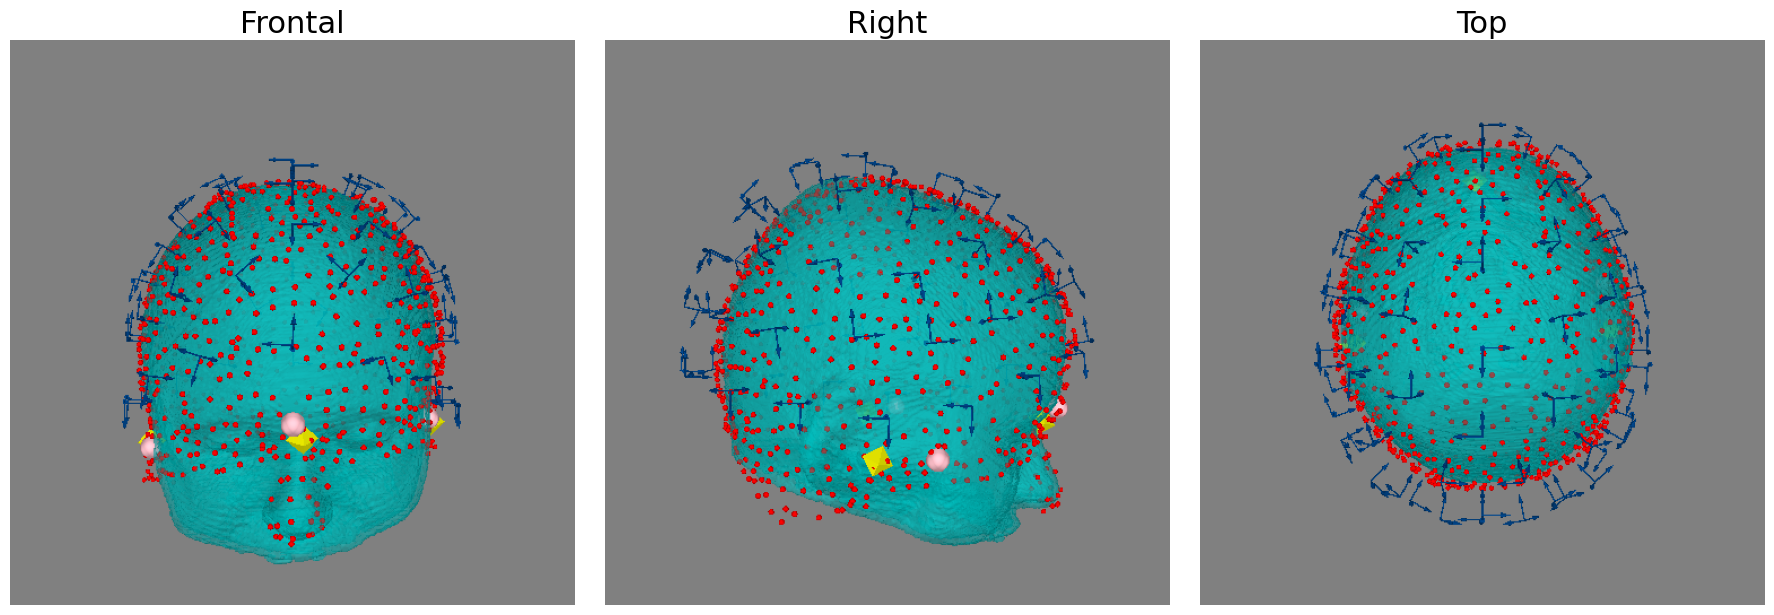

Coregistration complete.

Calculating forward model
-------------------------
Using bet_inskull_surf_file for single shell surface
Surface CM = (   0.6   -6.4   51.4) mm
Surface fits inside a sphere with radius   85.6 mm
Surface extent:
    x =  -70.0 ...   70.5 mm
    y =  -82.8 ...   78.1 mm
    z =  -19.4 ...  114.7 mm
Grid extent:
    x =  -80.0 ...   80.0 mm
    y =  -96.0 ...   80.0 mm
    z =  -32.0 ...  128.0 mm
1452 sources before omitting any.
638 sources after omitting infeasible sources not within 0.0 - 85.6 mm.
Source spaces are in MRI coordinates.
Checking that the sources are inside the surface and at least    4.0 mm away (will take a few...)
Checking surface interior status for 638 points...
    Found  16/638 points inside  an interior sphere of radius   25.7 mm
    Found   0/638 points outside an exterior sphere of radius   85.6 mm
    Found 280/622 points outside using surface Qhull
    Found  36/342 points outside using solid angles
    Total 322/638 points inside th

pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-04-01 00:20:19 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-04-01 00:20:19 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1


Applying LCMV beamformer complete.

Parcellating data
-----------------
gridstep = 8 mm
Resampled parcellation: /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-001_task-braille_run-001/src/atlas-Glasser_nparc-52_space-MNI_res-8x8x8_8mm.nii.gz
Finding nearest neighbour voxel


Calculating parcel time courses with spatial_basis
Performing symmetric orthogonalisation
Saving /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-001_task-braille_run-001/lcmv-parc-raw.fif
Omitting 4500 of 359253 (1.25%) samples, retaining 354753 (98.75%) samples.
Creating RawArray with float64 data, n_channels=52, n_times=359253
    Range : 0 ... 359252 =      0.000 ...  1437.008 secs
Ready.
Creating RawArray with float64 data, n_channels=27, n_times=359253
    Range : 0 ... 359252 =      0.000 ...  1437.008 secs
Ready.
Writing /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-001_task-braille_run-001/lcmv-parc-raw.fif
Closing /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-001_task-braille_run-001/lcmv-parc-raw.fif
[done]
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-001_task-braille_run-001/lcmv-parc-raw.fif...
 

pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-04-01 00:20:35 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-04-01 00:20:35 INFO osl-dynamics [plotting.py:107:save]: Saving /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-001_task-braille_run-001/parc_psds.png


Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_old/derivatives_anna_opm_5/preprocessed/sub-001_ses-002_task-braille_run-001_preproc-raw.fif...
    Range : 0 ... 363306 =      0.000 ...  1453.224 secs
Ready.
Reading 0 ... 363306  =      0.000 ...  1453.224 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 45 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (effective, after forward-backward)
- Cutoffs at 4.00, 45.00 Hz: -6.02, -6.02 dB


Extracting fiducials/headshape points from fif info
---------------------------------------------------
Saved: /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-002_task-braille_run-001/coreg/head_nasion.txt
Saved: /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-002_task-braille_run-001/coreg/head_rpa.txt
Saved

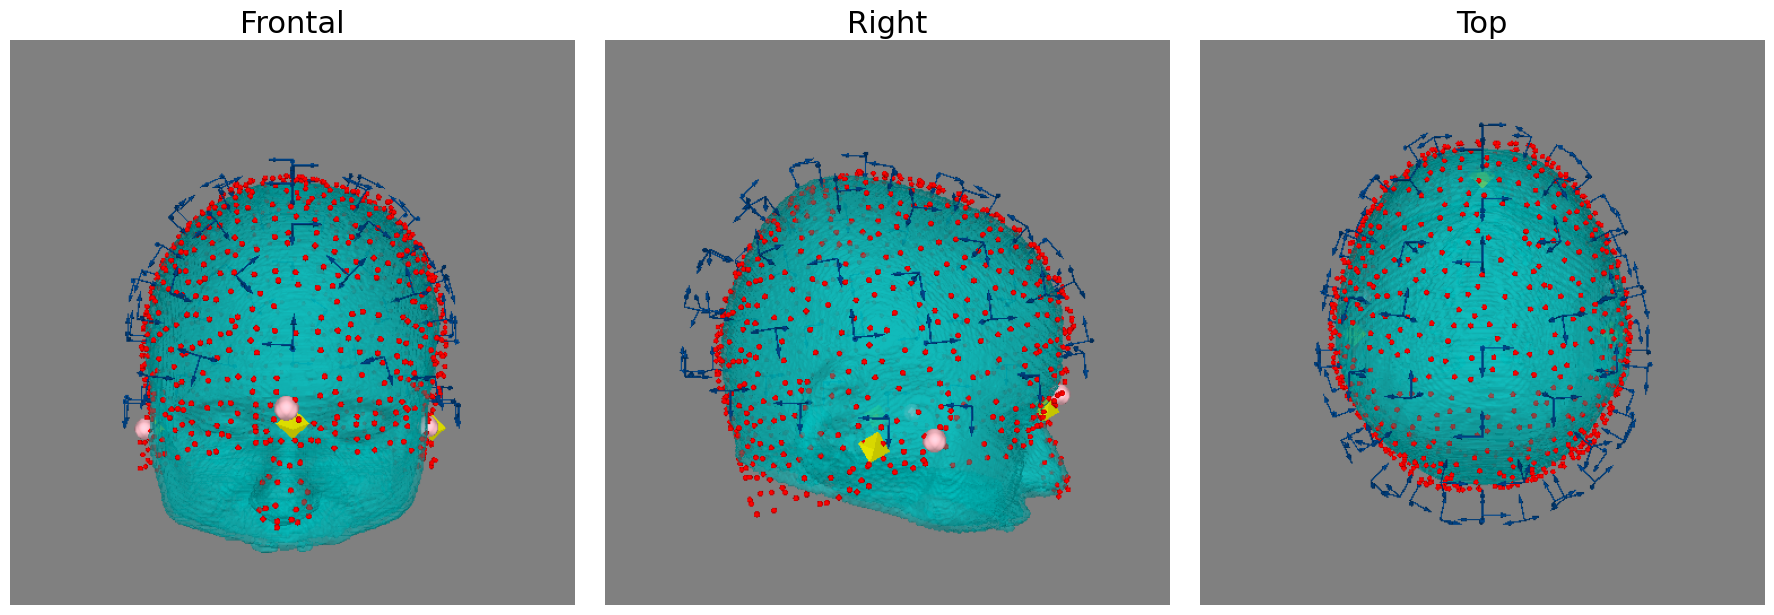

Coregistration complete.

Calculating forward model
-------------------------
Using bet_inskull_surf_file for single shell surface
Surface CM = (   0.6   -6.4   51.4) mm
Surface fits inside a sphere with radius   85.6 mm
Surface extent:
    x =  -70.0 ...   70.5 mm
    y =  -82.8 ...   78.1 mm
    z =  -19.4 ...  114.7 mm
Grid extent:
    x =  -80.0 ...   80.0 mm
    y =  -96.0 ...   80.0 mm
    z =  -32.0 ...  128.0 mm
1452 sources before omitting any.
638 sources after omitting infeasible sources not within 0.0 - 85.6 mm.
Source spaces are in MRI coordinates.
Checking that the sources are inside the surface and at least    4.0 mm away (will take a few...)
Checking surface interior status for 638 points...
    Found  16/638 points inside  an interior sphere of radius   25.7 mm
    Found   0/638 points outside an exterior sphere of radius   85.6 mm
    Found 280/622 points outside using surface Qhull
    Found  36/342 points outside using solid angles
    Total 322/638 points inside th

pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-04-01 00:21:17 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-04-01 00:21:17 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1


Applying LCMV beamformer complete.

Parcellating data
-----------------
gridstep = 8 mm
Resampled parcellation: /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-002_task-braille_run-001/src/atlas-Glasser_nparc-52_space-MNI_res-8x8x8_8mm.nii.gz
Finding nearest neighbour voxel


Calculating parcel time courses with spatial_basis
Performing symmetric orthogonalisation
Saving /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-002_task-braille_run-001/lcmv-parc-raw.fif
Omitting 1500 of 363307 (0.41%) samples, retaining 361807 (99.59%) samples.
Creating RawArray with float64 data, n_channels=52, n_times=363307
    Range : 0 ... 363306 =      0.000 ...  1453.224 secs
Ready.
Creating RawArray with float64 data, n_channels=27, n_times=363307
    Range : 0 ... 363306 =      0.000 ...  1453.224 secs
Ready.
Writing /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-002_task-braille_run-001/lcmv-parc-raw.fif
Closing /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-002_task-braille_run-001/lcmv-parc-raw.fif
[done]
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-002_task-braille_run-001/lcmv-parc-raw.fif...
 

pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-04-01 00:21:34 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-04-01 00:21:34 INFO osl-dynamics [plotting.py:107:save]: Saving /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-002_task-braille_run-001/parc_psds.png


Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_old/derivatives_anna_squid_4-45Hz/preprocessed/sub-001_ses-003_task-braille_run-001_preproc-raw.fif...
    Read 5 compensation matrices
    Range : 0 ... 337499 =      0.000 ...  1349.996 secs
Ready.
Current compensation grade : 3
Reading 0 ... 337499  =      0.000 ...  1349.996 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 45 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (effective, after forward-backward)
- Cutoffs at 4.00, 45.00 Hz: -6.02, -6.02 dB

Saving fiducials/headshape points from /rdrives/DRS-foundation-brain/zoe_data/BIDS/sub-001/ses-003/meg/sub-001_headshape.pos
Saved: /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-003_task-braille_run-001/coreg/head_nasion.txt
Saved: /rdrives/DRS-foundation-brain/zoe_data/BIDS/

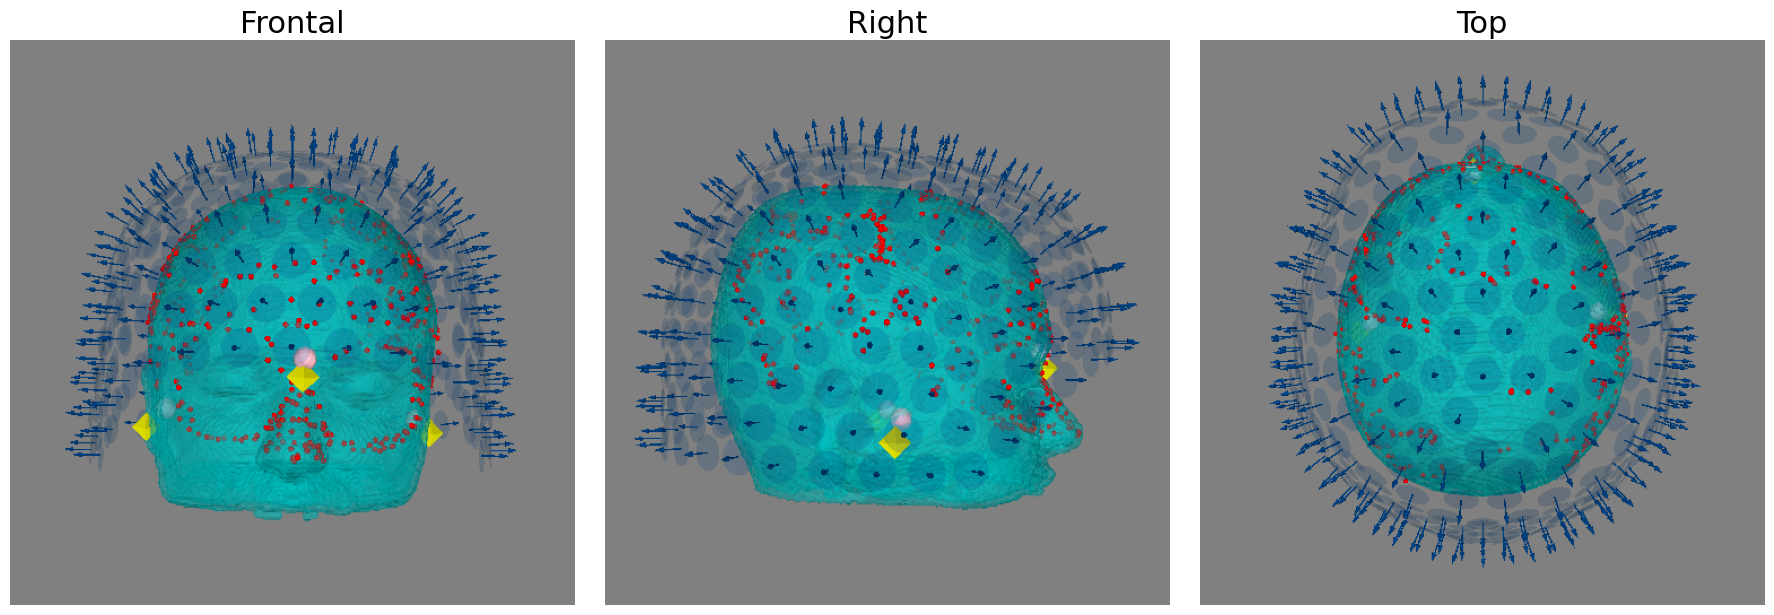

Coregistration complete.

Calculating forward model
-------------------------
Using bet_inskull_surf_file for single shell surface
Surface CM = (   0.6   -6.4   51.4) mm
Surface fits inside a sphere with radius   85.6 mm
Surface extent:
    x =  -70.0 ...   70.5 mm
    y =  -82.8 ...   78.1 mm
    z =  -19.4 ...  114.7 mm
Grid extent:
    x =  -80.0 ...   80.0 mm
    y =  -96.0 ...   80.0 mm
    z =  -32.0 ...  128.0 mm
1452 sources before omitting any.
638 sources after omitting infeasible sources not within 0.0 - 85.6 mm.
Source spaces are in MRI coordinates.
Checking that the sources are inside the surface and at least    4.0 mm away (will take a few...)
Checking surface interior status for 638 points...
    Found  16/638 points inside  an interior sphere of radius   25.7 mm
    Found   0/638 points outside an exterior sphere of radius   85.6 mm
    Found 280/622 points outside using surface Qhull
    Found  36/342 points outside using solid angles
    Total 322/638 points inside th

pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-04-01 00:22:24 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-04-01 00:22:24 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1


Applying LCMV beamformer complete.

Parcellating data
-----------------
gridstep = 8 mm
Resampled parcellation: /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-003_task-braille_run-001/src/atlas-Glasser_nparc-52_space-MNI_res-8x8x8_8mm.nii.gz
Finding nearest neighbour voxel


Calculating parcel time courses with spatial_basis
Performing symmetric orthogonalisation
Saving /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-003_task-braille_run-001/lcmv-parc-raw.fif
Omitting 2499 of 337500 (0.74%) samples, retaining 335001 (99.26%) samples.
Creating RawArray with float64 data, n_channels=52, n_times=337500
    Range : 0 ... 337499 =      0.000 ...  1349.996 secs
Ready.
Creating RawArray with float64 data, n_channels=2, n_times=337500
    Range : 0 ... 337499 =      0.000 ...  1349.996 secs
Ready.
Writing /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-003_task-braille_run-001/lcmv-parc-raw.fif
Closing /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-003_task-braille_run-001/lcmv-parc-raw.fif
[done]
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-003_task-braille_run-001/lcmv-parc-raw.fif...
  

pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-04-01 00:22:40 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-04-01 00:22:40 INFO osl-dynamics [plotting.py:107:save]: Saving /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-003_task-braille_run-001/parc_psds.png


Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_old/derivatives_anna_squid_4-45Hz/preprocessed/sub-001_ses-004_task-braille_run-001_preproc-raw.fif...
    Read 5 compensation matrices
    Range : 0 ... 337499 =      0.000 ...  1349.996 secs
Ready.
Current compensation grade : 3
Reading 0 ... 337499  =      0.000 ...  1349.996 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 45 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (effective, after forward-backward)
- Cutoffs at 4.00, 45.00 Hz: -6.02, -6.02 dB

Saving fiducials/headshape points from /rdrives/DRS-foundation-brain/zoe_data/BIDS/sub-001/ses-004/meg/sub-001_headshape.pos
Saved: /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-004_task-braille_run-001/coreg/head_nasion.txt
Saved: /rdrives/DRS-foundation-brain/zoe_data/BIDS/

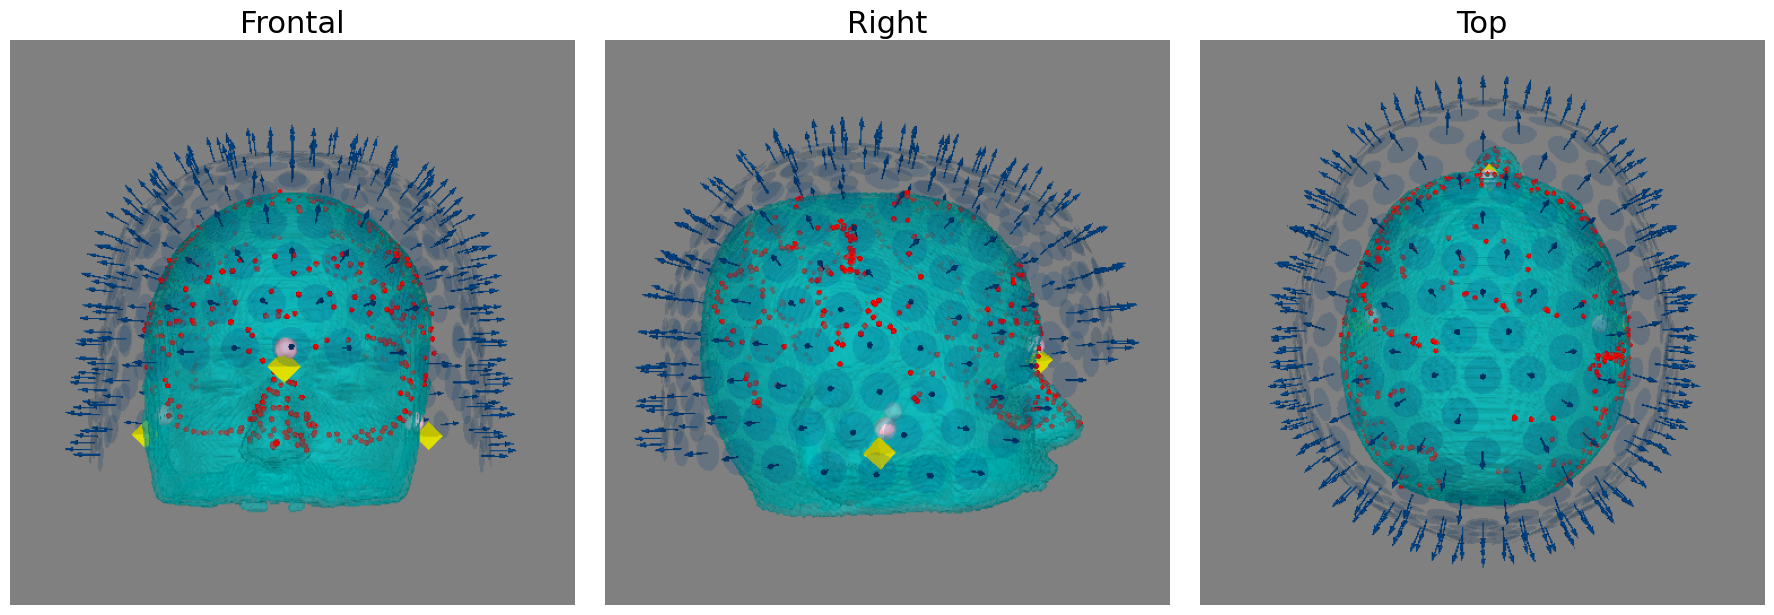

Coregistration complete.

Calculating forward model
-------------------------
Using bet_inskull_surf_file for single shell surface
Surface CM = (   0.6   -6.4   51.4) mm
Surface fits inside a sphere with radius   85.6 mm
Surface extent:
    x =  -70.0 ...   70.5 mm
    y =  -82.8 ...   78.1 mm
    z =  -19.4 ...  114.7 mm
Grid extent:
    x =  -80.0 ...   80.0 mm
    y =  -96.0 ...   80.0 mm
    z =  -32.0 ...  128.0 mm
1452 sources before omitting any.
638 sources after omitting infeasible sources not within 0.0 - 85.6 mm.
Source spaces are in MRI coordinates.
Checking that the sources are inside the surface and at least    4.0 mm away (will take a few...)
Checking surface interior status for 638 points...
    Found  16/638 points inside  an interior sphere of radius   25.7 mm
    Found   0/638 points outside an exterior sphere of radius   85.6 mm
    Found 280/622 points outside using surface Qhull
    Found  36/342 points outside using solid angles
    Total 322/638 points inside th

pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-04-01 00:23:30 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-04-01 00:23:30 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1


Applying LCMV beamformer complete.

Parcellating data
-----------------
gridstep = 8 mm
Resampled parcellation: /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-004_task-braille_run-001/src/atlas-Glasser_nparc-52_space-MNI_res-8x8x8_8mm.nii.gz
Finding nearest neighbour voxel


Calculating parcel time courses with spatial_basis
Performing symmetric orthogonalisation
Saving /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-004_task-braille_run-001/lcmv-parc-raw.fif
Omitting 6999 of 337500 (2.07%) samples, retaining 330501 (97.93%) samples.
Creating RawArray with float64 data, n_channels=52, n_times=337500
    Range : 0 ... 337499 =      0.000 ...  1349.996 secs
Ready.
Creating RawArray with float64 data, n_channels=2, n_times=337500
    Range : 0 ... 337499 =      0.000 ...  1349.996 secs
Ready.
Writing /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-004_task-braille_run-001/lcmv-parc-raw.fif
Closing /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-004_task-braille_run-001/lcmv-parc-raw.fif
[done]
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-004_task-braille_run-001/lcmv-parc-raw.fif...
  

pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-04-01 00:23:46 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-04-01 00:23:46 INFO osl-dynamics [plotting.py:107:save]: Saving /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_31032026/osl/sub-001_ses-004_task-braille_run-001/parc_psds.png


In [ ]:
#defining universal file locations
base = "/rdrives/DRS-foundation-brain/zoe_data/BIDS"
deriv = f"{base}/derivatives_anna_31032026"
outdir_osl= f"{deriv}/osl"
outdir_beam= f"{deriv}/beamformed"
os.makedirs(outdir_osl, exist_ok=True)
os.makedirs(outdir_beam, exist_ok=True)

parcellation_file = "atlas-Glasser_nparc-52_space-MNI_res-8x8x8.nii.gz"

#subjects and sessions for opms
subjects = ['001']
sessions = ["001", "002"]
tasks = ["braille"]
runs = ["001"]

#OPMS
for subject in subjects:

    outdir_surf = (f"{deriv}/anat_surfaces/sub-{subject}")

    for session in sessions:
        for task in tasks:
            for run in runs:

                id = f"sub-{subject}_ses-{session}_task-{task}_run-{run}"
                #preproc_file = f"/rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_old/derivatives_anna_opm_5/preprocessed/{id}_preproc-raw.fif"
                parc_fif = (f"{outdir_osl}/{id}/lcmv-parc-raw.fif")
                psd_file = (f"{outdir_osl}/{id}/parc_psds.png")
                
                source_space(id, preproc_file, outdir_surf, outdir_osl, outdir_beam, parc_fif, parcellation_file, posfile=None, mode='opm', psdfile=psd_file)


#SQUIDS
sessions = ["003", "004"]

for subject in subjects:

    outdir_surf = (f"{deriv}/anat_surfaces/sub-{subject}")

    for session in sessions:
        for task in tasks:
            for run in runs:

                id = f"sub-{subject}_ses-{session}_task-{task}_run-{run}"
                #preproc_file = f"/rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_old/derivatives_anna_squid_4-45Hz/preprocessed/{id}_preproc-raw.fif"
                posfile = f"/rdrives/DRS-foundation-brain/zoe_data/BIDS/sub-{subject}/ses-{session}/meg/sub-{subject}_headshape.pos"
                parc_fif = (f"{outdir_osl}/{id}/lcmv-parc-raw.fif")
                psd_file = (f"{outdir_osl}/{id}/parc_psds.png")
                
                source_space(id, preproc_file, outdir_surf, outdir_osl, outdir_beam, parc_fif, parcellation_file, posfile=posfile, mode='squid', psdfile=psd_file)